# 01. LangGraph Functional API: @entrypoint와 @task

> 그래프 빌더 API가 부담스럽다면 `@entrypoint` · `@task` 데코레이터만으로도 같은 LangGraph 기능을 쓸 수 있어요. 함수형 스타일이 잘 어울리는 케이스를 골라 비교해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. `@entrypoint`와 `@task` 데코레이터를 사용해 워크플로우를 함수형으로 정의할 수 있어요
2. Graph API와 Functional API의 차이를 설명하고 적절한 상황에 각 API를 선택할 수 있어요
3. `previous`, `store`, `writer`, `config` Injectable 파라미터를 활용할 수 있어요
4. `entrypoint.final`로 반환값과 저장값을 분리하고, 병렬 실행으로 성능을 높일 수 있어요
5. `interrupt`와 `Command(resume=)`을 Functional API에서 사용해 Human-in-the-Loop를 구현할 수 있어요

## 사전 지식

- Part 02: StateGraph, Node, Edge, START/END로 그래프 구성 방법
- Part 02: InMemorySaver, thread_id를 이용한 체크포인팅
- Part 03: LangGraph의 "Thinking" 방식, 워크플로우 vs 에이전트 구분, 5가지 사고 도구(Constrain·Inform·Verify·Correct·HITL)

## 이전 챕터와의 연결 — 이번 챕터가 5가지 도구의 어디를 심화하나요?

Part 03/03에서 배운 5가지 사고 도구는 03~13장 전체의 공통 언어예요. Part 04(LangGraph Advanced)는 그중에서도 주로 **Correct** 와 **HITL** 을 깊이 다져요.

| Part 04 레슨 | 주로 강화하는 사고 도구 | 이유 |
|-------------|------------------------|------|
| **01 Functional API** (이 노트북) | Correct | `@task` 결과를 체크포인트에 기록해 실패 지점부터 자동 재개 — 실패를 "다음 호출에 정보를 더해" 복구하는 원리의 기반 |
| **02 Subgraphs** | Constrain + Inform | 하위 그래프로 책임을 나누면 컨텍스트와 도구 권한을 계층적으로 제한 |
| **03 Branching-Parallel** | Constrain | Superstep 트랜잭션과 `defer=True`로 동시 실행 순서·병합을 안전하게 통제 |
| **04 Durable Execution** | Correct | `RetryPolicy` + 내구성 실행으로 네트워크·리소스 오류를 자동 복구 |
| **05 DeleteMessages** / **06 Conversation-Summary** | Inform | 긴 맥락에서 "지금 꼭 보여줄 것만" 유지하는 메시지 수술법 |
| **07 Streaming-Steps** | (관찰성 보조) | 도구 선택은 아니지만 Verify/Correct를 실무에서 작동시키는 관찰 창구 |

이 노트북(01 Functional API)은 단순히 "또 하나의 API"가 아니라, 실패를 받아들이고도 전진하는 **Correct 도구**를 언어 수준에서 구현한 장치예요. Part 03의 `02-Design-Principles.ipynb`에서 StateGraph(Graph API)의 노드·엣지 사고방식을 익혔다면, 이번에는 일반 Python 함수에 데코레이터를 붙이는 것만으로 내구성 있는(durable) 워크플로우를 만드는 법을 살펴봐요.

## Functional API란?

LangGraph는 워크플로우를 정의하는 두 가지 방식을 제공해요.

| 특성 | Graph API (StateGraph) | Functional API (@entrypoint/@task) |
|------|----------------------|------------------------------------|
| 정의 방식 | 노드와 엣지를 명시적으로 선언 | 함수에 데코레이터를 붙여 정의 |
| 제어 흐름 | 그래프 토폴로지로 표현 | 일반 Python 제어 흐름 (if/for/while) |
| 상태 관리 | TypedDict State 스키마 | 함수 입출력 + 자동 체크포인팅 |
| 시각화 | 그래프 다이어그램 지원 | 제한적 (task 레벨만) |
| 학습 곡선 | 중간 (State 스키마 필요) | 낮음 (일반 Python 함수) |
| 복잡한 로직 | 조건 분기가 명시적 | Python 코드로 자연스럽게 표현 |
| 내구성 실행 | 지원 | 지원 |

> 🔑 **핵심 개념**: Functional API의 핵심은 **`@task` 함수 호출이 자동으로 체크포인트에 기록**된다는 거예요. 실패 후 재실행하면 이미 완료된 task는 캐시에서 결과를 가져오고 실패한 시점부터 다시 시작해요. 이것이 "내구성 있는 실행(Durable Execution)"이에요.

### 두 API의 아키텍처 비교

```mermaid
flowchart TB
    subgraph G ["Graph API - StateGraph"]
        direction LR
        GS["START"]:::input --> GN1["node_a"]:::process
        GN1 --> GN2["node_b"]:::process
        GN2 --> GN3["node_c"]:::process
        GN3 --> GE["END"]:::output
    end

    subgraph F ["Functional API - @entrypoint"]
        direction LR
        FE["@entrypoint"]:::input --> FT1["@task A"]:::process
        FT1 --> FT2["@task B"]:::process
        FT2 --> FT3["@task C"]:::process
        FT3 --> FR["return"]:::output
    end

    subgraph CP ["공통: Checkpointer"]
        direction LR
        CS[("체크포인트<br>저장소")]:::storage
    end

    G -.->|체크포인팅| CP
    F -.->|체크포인팅| CP

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
```

> 🎯 **강의 포인트**: Graph API는 "그래프를 그리고 거기에 로직을 채운다"는 방식이에요. 반면 Functional API는 "로직을 먼저 쓰고, 데코레이터가 내구성을 부여한다"는 방식이에요. 복잡한 동적 로직이나 기존 Python 코드를 LangGraph로 전환할 때 Functional API가 훨씬 자연스러워요.

## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY 등을 불러와요
from dotenv import load_dotenv
load_dotenv()

# 환경 변수 로드 완료

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택)
# ---------------------------------------------------
# LangSmith로 워크플로우 실행을 추적하면 디버깅에 도움이 돼요
import os

# LangSmith API 키가 있는 경우 추적을 활성화해요
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-Functional-API"

# 설정 완료

## 1. 기본 사용법: @entrypoint와 @task

Functional API의 두 핵심 데코레이터를 소개해요:

- **`@task`**: 개별 작업 단위를 정의해요. 체크포인트에 결과가 기록되며, 재실행 시 캐시에서 결과를 반환해요.
- **`@entrypoint`**: 워크플로우의 진입점이에요. `@task`들을 조합해 전체 흐름을 정의하고, 체크포인터와 연결해요.

### Graph API vs Functional API: 코드 스타일 비교

```python
# Graph API: "그래프를 그리고 로직을 채운다"
builder = StateGraph(State)
builder.add_node("step1", step1_fn)
builder.add_node("step2", step2_fn)
builder.add_edge("step1", "step2")
graph = builder.compile(checkpointer=saver)

# Functional API: "로직을 쓰고 데코레이터가 내구성을 부여한다"
@entrypoint(checkpointer=saver)
def workflow(input):
    result1 = step1_task(input).result()
    result2 = step2_task(result1).result()
    return result2
```

> ⚠️ **자주 하는 실수**: `@task` 함수를 호출하면 즉시 실행되지 않아요. 내부적으로 **Future 객체**를 반환해요. 실제 결과는 `.result()` 또는 `await`로 가져와야 해요. 이 점이 일반 함수와 가장 다른 부분이에요.

> 🔑 **핵심 개념**: `@task` 함수는 **직렬화 가능한(serializable) 값만 반환**해야 해요. `dict`, `list`, `str`, `int`, `float`, Pydantic 모델 등은 괜찮지만, Lambda 함수나 데이터베이스 커넥션 같은 직렬화 불가능한 객체는 반환하면 안 돼요.

In [3]:
# ---------------------------------------------------
# 기본 Functional API 예제
# ---------------------------------------------------
# LangGraph Functional API의 핵심 데코레이터를 가져와요
from langgraph.func import entrypoint, task

# 체크포인팅을 위한 인메모리 저장소
from langgraph.checkpoint.memory import InMemorySaver

# LangChain V1 방식으로 모델 초기화
from langchain.chat_models import init_chat_model

# 기본 모델: gpt-4o-mini (비용 효율적)
# 다른 모델: "anthropic:claude-sonnet-4-5", "google_genai:gemini-2.0-flash"
model = init_chat_model("openai:gpt-4o-mini")

# 체크포인터: 실행 상태를 메모리에 저장해요
checkpointer = InMemorySaver()


# @task: 개별 작업 단위 - 결과가 체크포인트에 기록돼요
@task
def call_model(prompt: str) -> str:
    """모델을 호출해 응답을 반환하는 task예요"""
    from langchain.messages import HumanMessage
    # task 내부에서 모델을 호출해요
    response = model.invoke([HumanMessage(content=prompt)])
    return response.content


# @entrypoint: 워크플로우의 진입점 - 체크포인터와 연결해요
@entrypoint(checkpointer=checkpointer)
def my_workflow(topic: str) -> str:
    """주제에 대한 설명을 생성하는 워크플로우예요"""
    # task를 호출하면 Future를 반환해요
    # .result()로 실제 값을 가져와요
    result = call_model(f"{topic}에 대해 한 문장으로 설명해줘").result()
    return result


# Functional API 정의 완료
# my_workflow는 이제 내구성 있는 워크플로우예요

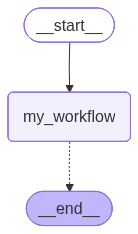

In [4]:
# 그래프 흐름: @entrypoint → call_model(@task) → return
# my_workflow: 주제에 대한 설명을 생성하는 Functional API 워크플로우예요
# @task(call_model)가 체크포인트에 기록되어 재실행 시 캐시에서 결과를 가져와요
from IPython.display import Image, display
display(Image(my_workflow.get_graph().draw_mermaid_png()))

In [5]:
# ---------------------------------------------------
# 워크플로우 실행하기
# ---------------------------------------------------
# thread_id: 실행 세션을 구분해요 (체크포인팅 핵심 키)
# Graph API와 동일하게 config["configurable"]["thread_id"]를 사용해요
config = {"configurable": {"thread_id": "thread-001"}}

# invoke()로 워크플로우를 실행해요
result = my_workflow.invoke("인공지능", config=config)
# 실행 결과:
print(result)

인공지능은 인간의 지능을 모방하거나 시뮬레이션하여 학습, 추론, 문제 해결 등의 작업을 수행하는 컴퓨터 시스템이나 프로그램입니다.


In [6]:
# ---------------------------------------------------
# 스트리밍 실행
# ---------------------------------------------------
# stream()으로 실행 과정을 단계별로 볼 수 있어요
# 스트리밍 실행:
# ----------------------------------------

config2 = {"configurable": {"thread_id": "thread-002"}}

# stream_mode="updates": 각 task 완료 시 업데이트를 받아요
for chunk in my_workflow.stream("머신러닝", config=config2, stream_mode="updates"):
    print(f"업데이트: {chunk}")

업데이트: {'call_model': '머신러닝은 데이터로부터 학습하여 특정 작업을 자동으로 수행하거나 예측할 수 있도록 하는 인공지능의 한 분야입니다.'}
업데이트: {'my_workflow': '머신러닝은 데이터로부터 학습하여 특정 작업을 자동으로 수행하거나 예측할 수 있도록 하는 인공지능의 한 분야입니다.'}


## 2. 여러 task 조합하기

실제 워크플로우에서는 여러 task를 순서대로 실행하거나 조건에 따라 다르게 실행해요. Functional API에서는 일반 Python 코드로 이를 표현할 수 있어요.

> 💡 **실무 팁**: `@task`는 **결정론적(deterministic)**이고 **멱등적(idempotent)**이어야 해요. 같은 입력에 항상 같은 출력이 나와야 내구성 있는 재실행이 올바르게 동작해요. 외부 상태에 의존하거나 랜덤 값을 직접 생성하면 재실행 시 문제가 발생할 수 있어요.

In [7]:
# ---------------------------------------------------
# 여러 task를 순서대로 실행하는 워크플로우
# ---------------------------------------------------
from langgraph.func import entrypoint, task
from langgraph.checkpoint.memory import InMemorySaver
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

model2 = init_chat_model("openai:gpt-4o-mini")
checkpointer2 = InMemorySaver()


@task
def generate_outline(topic: str) -> str:
    """주제에 대한 개요를 생성해요"""
    prompt = f"{topic}에 대한 글의 개요를 3가지 항목으로 작성해줘. 번호와 제목만 간단히."
    response = model2.invoke([HumanMessage(content=prompt)])
    return response.content


@task
def write_introduction(topic: str, outline: str) -> str:
    """개요를 바탕으로 서론을 작성해요"""
    prompt = f"다음 개요를 바탕으로 '{topic}'에 대한 서론을 2-3문장으로 써줘.\n개요:\n{outline}"
    response = model2.invoke([HumanMessage(content=prompt)])
    return response.content


@task
def create_summary(topic: str, intro: str) -> str:
    """서론을 바탕으로 한 줄 요약을 만들어요"""
    prompt = f"다음 서론을 한 문장으로 요약해줘.\n서론:\n{intro}"
    response = model2.invoke([HumanMessage(content=prompt)])
    return response.content


@entrypoint(checkpointer=checkpointer2)
def writing_workflow(topic: str) -> dict:
    """개요 → 서론 → 요약 순으로 실행하는 글쓰기 워크플로우예요"""
    # 1단계: 개요 생성
    # .result()를 호출해야 실제 값을 받아요
    outline = generate_outline(topic).result()

    # 2단계: 서론 작성 (개요를 입력으로 사용)
    intro = write_introduction(topic, outline).result()

    # 3단계: 요약 생성 (서론을 입력으로 사용)
    summary = create_summary(topic, intro).result()

    # 딕셔너리로 모든 결과를 반환해요
    return {
        "topic": topic,
        "outline": outline,
        "introduction": intro,
        "summary": summary
    }


# 실행
config3 = {"configurable": {"thread_id": "writing-001"}}
result = writing_workflow.invoke("딥러닝", config=config3)

print(f"주제: {result['topic']}")
print(f"\n[개요]\n{result['outline']}")
print(f"\n[서론]\n{result['introduction']}")
print(f"\n[한 줄 요약]\n{result['summary']}")

주제: 딥러닝

[개요]
1. 딥러닝의 정의 및 원리  
2. 주요 응용 분야  
3. 딥러닝의 장단점 및 미래 전망  

[서론]
딥러닝은 인공 신경망을 기반으로 한 머신러닝의 한 분야로, 대량의 데이터를 통해 복잡한 패턴을 학습하고 예측하는 기술입니다. 최근 다양한 산업 분야에서 이미지 인식, 자연어 처리, 자율주행차 등으로 응용되고 있으며, 그 성능과 효율성 덕분에 미래의 기술 혁신을 이끌 것으로 기대됩니다. 그러나 데이터 요구량과 해석의 어려움 등 몇 가지 도전 과제도 동반하고 있습니다.

[한 줄 요약]
딥러닝은 인공 신경망을 기반으로 대량의 데이터를 활용해 복잡한 패턴을 학습하고 예측하는 기술로, 다양한 산업에 응용되고 있지만 데이터 요구량과 해석의 어려움 등의 도전 과제가 존재합니다.


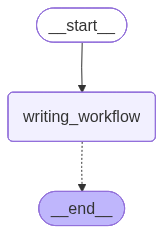

In [8]:
# 그래프 흐름: @entrypoint → generate_outline → write_introduction → create_summary → return
# writing_workflow: 개요 → 서론 → 요약 순으로 3개의 @task를 순차 실행해요
# 각 task는 이전 task의 결과를 입력으로 사용해요
display(Image(writing_workflow.get_graph().draw_mermaid_png()))

## 3. 병렬 실행

Functional API의 강점 중 하나는 여러 task를 **병렬로** 실행할 수 있다는 거예요.

### 순차 실행 vs 병렬 실행

```mermaid
flowchart LR
    subgraph SEQ["순차 실행 (느림)"]
        direction LR
        S1["Task A<br/>2초"] --> S2["Task B<br/>2초"] --> S3["Task C<br/>2초"]
    end

    subgraph PAR["병렬 실행 (빠름)"]
        direction TB
        P0["Future 생성"] --> P1["Task A<br/>2초"]
        P0 --> P2["Task B<br/>2초"]
        P0 --> P3["Task C<br/>2초"]
        P1 --> P4[".result() 수집"]
        P2 --> P4
        P3 --> P4
    end

    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    class S1,S2,S3,P1,P2,P3 process
    class P0,P4 output
```

| 방식 | 코드 패턴 | 총 소요 시간 (각 2초일 때) |
|------|-----------|------------------------|
| 순차 | `a = task_a(x).result(); b = task_b(x).result()` | 6초 (2+2+2) |
| 병렬 | `futures = [task_a(x), task_b(x), task_c(x)]; results = [f.result() for f in futures]` | 2초 (가장 긴 task 기준) |

> 🎯 **강의 포인트**: 아래 코드에서 핵심은 순서예요. `task1.result()`, `task2.result()`, `task3.result()`를 **순서대로** 호출하면 순차 실행이에요. 반면 `[t() for t in tasks]`로 Future를 먼저 모두 만들고 나서 결과를 수집하면 **병렬 실행**이 돼요. 이 패턴을 잘 기억해두세요.

In [9]:
# ---------------------------------------------------
# 병렬 실행 패턴: 먼저 모두 호출하고 나서 결과 수집
# ---------------------------------------------------
import time
from langgraph.func import entrypoint, task
from langgraph.checkpoint.memory import InMemorySaver
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

model3 = init_chat_model("openai:gpt-4o-mini")
checkpointer3 = InMemorySaver()


@task
def analyze_perspective(topic: str, perspective: str) -> str:
    """특정 관점에서 주제를 분석해요"""
    prompt = f"'{topic}'을 {perspective} 관점에서 한 문장으로 설명해줘."
    response = model3.invoke([HumanMessage(content=prompt)])
    return response.content


@entrypoint(checkpointer=checkpointer3)
def parallel_analysis(topic: str) -> dict:
    """여러 관점에서 동시에 분석하는 워크플로우예요"""
    perspectives = ["기술적", "경제적", "사회적"]

    # 핵심 패턴: 먼저 모든 task를 호출해 Future 목록을 만들어요
    # 이 시점에서 세 task가 병렬로 시작돼요
    futures = [analyze_perspective(topic, p) for p in perspectives]

    # 그 다음 각 Future에서 결과를 수집해요
    # 가장 오래 걸리는 task가 끝날 때까지 대기해요
    results = [f.result() for f in futures]

    return {
        perspective: result
        for perspective, result in zip(perspectives, results)
    }


# 실행 시간 측정
config4 = {"configurable": {"thread_id": "parallel-001"}}

start = time.time()
result = parallel_analysis.invoke("자율주행 자동차", config=config4)
elapsed = time.time() - start

print(f"실행 시간: {elapsed:.1f}초 (3개 task가 병렬로 실행됨)")
print()
for perspective, analysis in result.items():
    print(f"[{perspective} 관점]")
    print(f"  {analysis}")
    print()

실행 시간: 1.7초 (3개 task가 병렬로 실행됨)

[기술적 관점]
  자율주행 자동차는 센서, 인공지능, 머신러닝 알고리즘을 활용하여 주행 환경을 인식하고 판단하여 인간의 개입 없이 자율적으로 주행하는 차량이다.

[경제적 관점]
  자율주행 자동차는 인건비 절감, 교통사고 감소, 물류 효율성 향상 등을 통해 경제적 가치를 창출하며, 교통 시스템의 혁신을 이끄는 중요한 기술로 자리잡고 있다.

[사회적 관점]
  자율주행 자동차는 운전자의 개입 없이 자동차가 스스로 주행할 수 있도록 하는 기술로, 교통 안전 향상, 도로 효율성 증대, 및 교통 혼잡 완화 등 사회적 이점을 제공할 수 있다.



In [10]:
# ---------------------------------------------------
# 순차 실행 vs 병렬 실행 비교
# ---------------------------------------------------
# ============================================================
# TODO: 순차 실행 버전을 작성해보고 병렬 실행과 시간을 비교해요
# 힌트: 아래 코드에서 Future를 먼저 모두 만들지 말고
#       각 task마다 즉시 .result()를 호출하면 순차 실행이 돼요
# 예상 결과: 순차 실행이 병렬 실행보다 약 2~3배 느릴 거예요
# ============================================================

@entrypoint(checkpointer=InMemorySaver())
def sequential_analysis(topic: str) -> dict:
    """순차 실행 버전 - 각 task를 하나씩 순서대로 실행해요"""
    perspectives = ["기술적", "경제적", "사회적"]
    results = {}

    for perspective in perspectives:
        # 각 task 호출 즉시 .result()를 붙이면 순차 실행
        # 앞 task가 끝나야 다음 task가 시작돼요
        result = analyze_perspective(topic, perspective).result()
        results[perspective] = result

    return results


config5 = {"configurable": {"thread_id": "sequential-001"}}

start = time.time()
result = sequential_analysis.invoke("자율주행 자동차", config=config5)
elapsed = time.time() - start

print(f"순차 실행 시간: {elapsed:.1f}초")
# (병렬 실행과 비교해보세요)

순차 실행 시간: 4.4초


## 4. Injectable 파라미터

Functional API는 `@entrypoint` 함수에 특별한 파라미터를 **자동으로 주입**할 수 있어요. 이를 **Injectable 파라미터**라고 해요.

| 파라미터 | 타입 | 설명 |
|---------|------|------|
| `previous` | 이전 반환값 타입 | 이전 실행의 반환값 (대화 이력 유지에 활용) |
| `store` | `BaseStore` | 크로스 스레드 장기 기억 저장소 |
| `writer` | `StreamWriter` | 커스텀 스트리밍 청크를 내보내는 함수 |
| `config` | `RunnableConfig` | 실행 설정 (thread_id, 사용자 ID 등) |

> 🔑 **핵심 개념**: `previous`는 체크포인터가 있을 때 자동으로 이전 실행의 반환값을 주입해줘요. 대화형 워크플로우에서 이전 대화 내용을 기억하는 데 핵심 역할을 해요. 체크포인터 없이는 사용할 수 없어요.

In [11]:
# ---------------------------------------------------
# previous 파라미터: 이전 실행 결과를 자동으로 주입받아요
# ---------------------------------------------------
from langgraph.func import entrypoint, task
from langgraph.checkpoint.memory import InMemorySaver
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from typing import Optional

model4 = init_chat_model("openai:gpt-4o-mini")
checkpointer4 = InMemorySaver()


@task
def chat_with_history(message: str, history: list) -> str:
    """대화 이력을 포함해 모델을 호출해요"""
    # 시스템 메시지 + 이력 + 새 메시지를 합쳐서 전달
    messages = [
        SystemMessage(content="당신은 친절한 AI 어시스턴트입니다."),
        *history,  # 이전 대화 이력을 펼쳐서 추가
        HumanMessage(content=message)
    ]
    response = model4.invoke(messages)
    return response.content


@entrypoint(checkpointer=checkpointer4)
def conversation(
    message: str,
    *,
    previous: Optional[dict] = None  # 이전 실행의 반환값이 자동으로 주입돼요
) -> dict:
    """대화 이력을 유지하는 대화형 워크플로우예요"""
    # 첫 실행이면 빈 이력, 재실행이면 이전 이력 사용
    history = previous["messages"] if previous else []

    # 모델 호출
    response = chat_with_history(message, history).result()

    # 새 메시지를 이력에 추가해서 반환
    # 이 반환값이 다음 실행의 previous에 주입돼요
    updated_history = history + [
        {"role": "human", "content": message},
        {"role": "assistant", "content": response}
    ]

    return {
        "response": response,
        "messages": updated_history
    }


# 같은 thread_id로 대화를 이어가요
conv_config = {"configurable": {"thread_id": "chat-001"}}

# 첫 번째 메시지
result1 = conversation.invoke("안녕! 내 이름은 철수야.", config=conv_config)
print(f"1번 응답: {result1['response']}")

# 두 번째 메시지 - 이름을 기억하는지 확인
result2 = conversation.invoke("내 이름이 뭔지 기억해?", config=conv_config)
print(f"2번 응답: {result2['response']}")

# 세 번째 메시지
result3 = conversation.invoke("LangGraph가 뭔지 간단히 설명해줘", config=conv_config)
print(f"3번 응답: {result3['response'][:200]}...")

1번 응답: 안녕, 철수! 만나서 반가워. 어떻게 도와줄 수 있을까?
2번 응답: 네, 당신의 이름은 철수라고 하셨죠! 다른 질문이나 이야기하고 싶은 주제가 있으면 언제든지 말해 주세요.
3번 응답: LangGraph는 자연어 처리(NLP)와 관련된 기술로, 언어의 구조와 의미를 그래프 형태로 표현하는 방법입니다. 이는 단어, 문장, 개체 등을 노드로 나타내고 이들 간의 관계를 엣지로 연결하여 텍스트 데이터의 의미를 더 잘 이해하고 분석할 수 있게 도와줍니다. LangGraph는 특히 다양한 언어 모델과 결합하여 언어의 맥락을 이해하는 데 유용하게 사용...


In [ ]:
# ---------------------------------------------------
# config 파라미터: 실행 설정 정보를 주입받아요
# ---------------------------------------------------
from langgraph.func import entrypoint, task
from langgraph.checkpoint.memory import InMemorySaver
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage
from langchain_core.runnables import RunnableConfig
from typing import Optional

model5 = init_chat_model("openai:gpt-4o-mini")
checkpointer5 = InMemorySaver()


@entrypoint(checkpointer=checkpointer5)
def configurable_workflow(
    message: str,
    *,
    config: RunnableConfig  # 실행 config가 자동으로 주입돼요
) -> dict:
    """config에서 사용자 정보를 읽어 개인화된 응답을 생성해요"""
    # configurable에서 사용자 정보를 읽어요
    configurable = config.get("configurable", {})
    thread_id = configurable.get("thread_id", "unknown")
    user_name = configurable.get("user_name", "사용자")
    language = configurable.get("language", "한국어")

    # 개인화된 프롬프트 생성
    prompt = f"{language}로 답변해줘. 사용자 이름: {user_name}\n질문: {message}"
    response = model5.invoke([HumanMessage(content=prompt)])

    return {
        "thread_id": thread_id,
        "user_name": user_name,
        "response": response.content
    }


# config에 사용자 정보를 포함해 실행
custom_config = {
    "configurable": {
        "thread_id": "user-alice-001",
        "user_name": "Alice",
        "language": "영어"  # 영어로 응답하도록 설정
    }
}

result = configurable_workflow.invoke("오늘 날씨가 좋아요", config=custom_config)

print(f"Thread: {result['thread_id']}")
print(f"사용자: {result['user_name']}")
print(f"응답: {result['response']}")

Thread: user-alice-001
사용자: Alice
응답: Your name is Alice.


## 5. entrypoint.final: 반환값과 저장값 분리

기본적으로 `@entrypoint` 함수의 반환값은 호출자에게 전달되면서 동시에 체크포인트에도 저장돼요. 그런데 때로는 **반환할 값**과 **저장할 값**을 다르게 하고 싶을 때가 있어요.

이럴 때 `entrypoint.final(value=..., save=...)` 을 사용해요.

- `value`: 호출자에게 반환할 값 (예: 사용자에게 보여줄 응답)
- `save`: 체크포인트에 저장할 값 (예: 다음 실행에서 `previous`로 사용할 상태)

> 💡 **실무 팁**: `entrypoint.final`은 응답 크기를 줄이는 데 유용해요. 예를 들어 내부 처리 로그나 중간 결과는 저장(`save`)하되, 사용자에게는 최종 요약만 반환(`value`)할 수 있어요.

In [13]:
# ---------------------------------------------------
# entrypoint.final: 반환값과 저장값을 분리해요
# ---------------------------------------------------
from langgraph.func import entrypoint, task
from langgraph.checkpoint.memory import InMemorySaver
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage
from typing import Optional

model6 = init_chat_model("openai:gpt-4o-mini")
checkpointer6 = InMemorySaver()


@task
def generate_response(question: str) -> str:
    """질문에 대한 응답을 생성해요"""
    response = model6.invoke([HumanMessage(content=question)])
    return response.content


@entrypoint(checkpointer=checkpointer6)
def smart_workflow(
    question: str,
    *,
    previous: Optional[dict] = None
) -> entrypoint.final[dict, dict]:  # [return_type, save_type]: 호출자 반환값과 체크포인트 저장값의 타입
    """응답은 간결하게 반환하지만 내부 이력은 상세하게 저장해요"""
    # 이전 이력 수
    history_count = len(previous["history"]) if previous else 0

    # 모델 응답 생성
    response = generate_response(question).result()

    # 저장할 내부 상태: 상세 이력
    internal_state = {
        "history": (previous["history"] if previous else []) + [
            {"q": question, "a": response}
        ],
        "total_exchanges": history_count + 1
    }

    # 반환할 값: 간결한 응답만
    user_facing_value = {
        "answer": response,
        "exchange_number": history_count + 1
    }

    # value: 호출자에게 반환, save: 체크포인트에 저장
    return entrypoint.final(value=user_facing_value, save=internal_state)


final_config = {"configurable": {"thread_id": "final-001"}}

# 첫 번째 질문
r1 = smart_workflow.invoke("파이썬의 장점은?", config=final_config)
print(f"교환 #{r1['exchange_number']}: {r1['answer'][:100]}...")

# 두 번째 질문
r2 = smart_workflow.invoke("그 중 가장 중요한 것은?", config=final_config)
print(f"교환 #{r2['exchange_number']}: {r2['answer'][:100]}...")

# (내부적으로는 전체 대화 이력이 체크포인트에 저장되어 있어요)

교환 #1: 파이썬의 장점은 여러 가지가 있습니다:

1. **간결하고 읽기 쉬운 문법**: 파이썬은 코드가 직관적이고, 가독성이 높아 초보자도 쉽게 배울 수 있습니다. 코드 블록을 들여쓰기로...
교환 #2: "그 중 가장 중요한 것은?"이라는 질문은 상황이나 맥락에 따라 다르게 해석될 수 있습니다. 무엇에 대해 이야기하고 있는지에 따라 중요성이 달라질 수 있는데, 예를 들어, 특정 주...


## 6. Human-in-the-Loop: interrupt와 Command

Functional API에서도 Graph API와 동일하게 `interrupt()`로 워크플로우를 일시 중지하고 사람의 입력을 기다릴 수 있어요.

### 실행 흐름

```mermaid
flowchart LR
    A["@entrypoint 시작"] --> B["@task: 초안 생성"]
    B --> C["interrupt()<br/>실행 중지"]
    C -->|"사람이 검토"| D["Command(resume=피드백)"]
    D --> E["@task: 피드백 반영"]
    E --> F["return 최종 결과"]

    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef pause fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef human fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class A,B,E,F process
    class C pause
    class D human
```

흐름:
1. 워크플로우 실행 중 `interrupt(value)` 호출 -> 실행 중지, `value`를 호출자에게 전달
2. 사람이 검토 후 `Command(resume=...)` 로 재실행
3. `interrupt()` 는 `resume` 값을 반환하며 실행 재개

> ⚠️ **자주 하는 실수**: `interrupt()`는 `@entrypoint` 함수 안에서 직접 호출해야 해요. `@task` 안에서는 동작하지 않아요. 또한 interrupt 후 재실행 시 **반드시 같은 `thread_id`** 를 사용해야 해요.

In [14]:
# ---------------------------------------------------
# interrupt + Command(resume=): 사람의 승인이 필요한 워크플로우
# ---------------------------------------------------
from langgraph.func import entrypoint, task
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

model7 = init_chat_model("openai:gpt-4o-mini")
checkpointer7 = InMemorySaver()


@task
def generate_draft(topic: str) -> str:
    """초안을 생성해요"""
    prompt = f"'{topic}'에 대한 짧은 글을 2문장으로 써줘."
    response = model7.invoke([HumanMessage(content=prompt)])
    return response.content


@task
def finalize_content(draft: str, feedback: str) -> str:
    """피드백을 반영해 최종 글을 완성해요"""
    if feedback.lower() in ["승인", "ok", "yes", "좋아"]:
        return draft  # 피드백이 승인이면 그대로 반환
    prompt = f"다음 글을 피드백에 맞게 수정해줘.\n글:\n{draft}\n피드백:\n{feedback}"
    response = model7.invoke([HumanMessage(content=prompt)])
    return response.content


@entrypoint(checkpointer=checkpointer7)
def approval_workflow(topic: str) -> dict:
    """초안 생성 → 사람 검토 → 최종 완성 순으로 실행하는 워크플로우예요"""
    # 1단계: 초안 생성
    draft = generate_draft(topic).result()

    # 2단계: 사람의 검토를 기다려요 (워크플로우 일시 중지)
    # interrupt()는 draft를 호출자에게 전달하고 실행을 멈춰요
    human_feedback = interrupt({
        "action": "review_draft",
        "draft": draft,
        "message": "초안을 검토하고 피드백을 주세요 (승인/수정 내용)"
    })

    # 3단계: 피드백을 받아 최종 완성 (interrupt()의 반환값이 피드백)
    final = finalize_content(draft, human_feedback).result()

    return {
        "topic": topic,
        "draft": draft,
        "feedback": human_feedback,
        "final": final
    }


hitl_config = {"configurable": {"thread_id": "hitl-001"}}

# 1번째 실행: 초안 생성 후 interrupt에서 멈춰요
# === 1단계: 초안 생성 ===
try:
    result = approval_workflow.invoke("기후 변화", config=hitl_config)
    print(f"결과: {result}")  # interrupt 전에 완료되면 여기에 도달
except Exception as e:
    # interrupt가 발생하면 GraphInterrupt 예외가 발생해요
    print(f"워크플로우 일시 중지: {type(e).__name__}")

# 체크포인트에서 현재 상태 확인
state = approval_workflow.get_state(hitl_config)
print(f"\n[체크포인트 상태]")
if state.tasks:
    for task_info in state.tasks:
        if hasattr(task_info, 'interrupts') and task_info.interrupts:
            print(f"  중단 정보: {task_info.interrupts[0].value}")

결과: {'__interrupt__': [Interrupt(value={'action': 'review_draft', 'draft': '기후 변화는 지구의 평균 기온 상승과 극한 기후 현상을 초래하며 인류와 생태계에 심각한 영향을 미치고 있습니다. 이를 해결하기 위해서는 지속 가능한 에너지 사용과 국제적인 협력이 필수적입니다.', 'message': '초안을 검토하고 피드백을 주세요 (승인/수정 내용)'}, id='0d796d50af51310c9068055dfeb2a587')]}

[체크포인트 상태]
  중단 정보: {'action': 'review_draft', 'draft': '기후 변화는 지구의 평균 기온 상승과 극한 기후 현상을 초래하며 인류와 생태계에 심각한 영향을 미치고 있습니다. 이를 해결하기 위해서는 지속 가능한 에너지 사용과 국제적인 협력이 필수적입니다.', 'message': '초안을 검토하고 피드백을 주세요 (승인/수정 내용)'}


In [15]:
# ---------------------------------------------------
# Command(resume=)로 워크플로우 재개하기
# ---------------------------------------------------
# 사람이 피드백을 제공하고 워크플로우를 재개해요
# Command(resume=값): interrupt() 함수가 이 값을 반환하면서 실행이 재개돼요
from langgraph.types import Command

# === 2단계: 피드백 제공 및 재개 ===

# 사람이 제공하는 피드백
feedback = "더 구체적인 해결책을 제시해줘"
print(f"제공할 피드백: {feedback}")

# Command(resume=피드백)으로 재실행 - 같은 thread_id를 사용해요
final_result = approval_workflow.invoke(
    Command(resume=feedback),
    config=hitl_config  # 반드시 같은 config (같은 thread_id)
)

print(f"\n[초안]\n{final_result['draft']}")
print(f"\n[피드백]\n{final_result['feedback']}")
print(f"\n[최종 결과]\n{final_result['final']}")

제공할 피드백: 더 구체적인 해결책을 제시해줘

[초안]
기후 변화는 지구의 평균 기온 상승과 극한 기후 현상을 초래하며 인류와 생태계에 심각한 영향을 미치고 있습니다. 이를 해결하기 위해서는 지속 가능한 에너지 사용과 국제적인 협력이 필수적입니다.

[피드백]
더 구체적인 해결책을 제시해줘

[최종 결과]
수정된 글:
기후 변화는 지구의 평균 기온 상승과 극한 기후 현상을 초래하며 인류와 생태계에 심각한 영향을 미치고 있습니다. 이를 해결하기 위해서는 지속 가능한 에너지 사용과 국제적인 협력이 필수적입니다. 구체적으로는 재생 가능 에너지인 태양광, 풍력, 수력 등의 사용을 늘리고, 에너지 효율을 높이기 위한 기술 개발을 추진해야 합니다. 또한, 각국은 탄소 배출을 줄이기 위한 정책을 마련하고, 국제적으로 협력하여 탄소 거래 시장을 활성화하며 기후 변화 대응 목표를 공유해야 합니다. 이러한 다각적인 노력이 모여 지속 가능한 미래를 만들어 갈 수 있을 것입니다.


## 7. retry_policy와 cache_policy

Functional API는 `@task` 데코레이터에 재시도 정책(`retry_policy`)과 캐시 정책(`cache_policy`)을 설정할 수 있어요.

- **`retry_policy`**: API 호출 실패 시 자동 재시도 설정
- **`cache_policy`**: 동일한 입력에 대해 이전 결과를 재사용

> 💡 **실무 팁**: `retry_policy`는 외부 API 호출이 포함된 task에 설정하면 일시적인 네트워크 오류나 속도 제한(rate limit)을 자동으로 처리할 수 있어요. 프로덕션 환경에서 필수적인 설정이에요.

> 🎯 **강의 포인트**: `cache_policy`를 사용하면 같은 입력이 다시 들어올 때 API를 호출하지 않고 저장된 결과를 반환해요. 비용 절감과 응답 속도 향상 모두에 효과적이에요. 특히 RAG 파이프라인에서 동일한 쿼리가 반복될 때 유용해요.

In [16]:
# ---------------------------------------------------
# retry_policy: 실패 시 자동 재시도 설정
# ---------------------------------------------------
from langgraph.func import entrypoint, task
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import RetryPolicy
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

model8 = init_chat_model("openai:gpt-4o-mini")
checkpointer8 = InMemorySaver()

# RetryPolicy: 재시도 정책 설정
# max_attempts: 최대 시도 횟수 (초기 1회 + 재시도 횟수)
# initial_interval: 첫 재시도 대기 시간(초)
# backoff_factor: 재시도마다 대기 시간 배수 (지수 백오프)
retry = RetryPolicy(
    max_attempts=3,       # 최대 3번 시도
    initial_interval=1.0, # 첫 재시도는 1초 후
    backoff_factor=2.0    # 2배씩 늘어남: 1초, 2초, 4초...
)


@task(retry_policy=retry)  # task에 retry_policy 적용
def resilient_api_call(prompt: str) -> str:
    """재시도 정책이 적용된 API 호출 task예요"""
    response = model8.invoke([HumanMessage(content=prompt)])
    return response.content


@entrypoint(checkpointer=checkpointer8)
def resilient_workflow(question: str) -> str:
    """API 오류에 강건한 워크플로우예요"""
    return resilient_api_call(question).result()


retry_config = {"configurable": {"thread_id": "retry-001"}}
result = resilient_workflow.invoke("LangGraph의 장점 한 문장으로", config=retry_config)
print(f"응답: {result}")
# 재시도 정책 적용 완료 (네트워크 오류 시 자동으로 최대 3번 재시도해요)

응답: LangGraph는 언어 모델 간의 관계를 시각화하고 분석하여 자연어 처리의 효율성을 향상시키는 동시에 다양한 언어적 정보를 통합할 수 있는 강력한 도구입니다.


In [17]:
# ---------------------------------------------------
# cache_policy: 동일 입력 재실행 시 캐시에서 반환
# ---------------------------------------------------
import time
from langgraph.func import entrypoint, task
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.cache.memory import InMemoryCache
from langgraph.types import CachePolicy
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

model9 = init_chat_model("openai:gpt-4o-mini")
checkpointer9 = InMemorySaver()

# 인메모리 캐시 생성
cache = InMemoryCache()


@task(cache_policy=CachePolicy(ttl=120))  # 결과를 120초 동안 캐시해요
def cached_analysis(keyword: str) -> str:
    """결과를 캐시하는 분석 task예요"""
    response = model9.invoke([
        HumanMessage(content=f"'{keyword}'의 핵심 의미를 한 문장으로")
    ])
    return response.content


@entrypoint(checkpointer=checkpointer9, cache=cache)  # cache= 에 InMemoryCache 인스턴스를 전달
def cached_workflow(keyword: str) -> str:
    """캐시 정책이 적용된 워크플로우예요"""
    return cached_analysis(keyword).result()


# 첫 번째 실행: 실제 API 호출
config_c1 = {"configurable": {"thread_id": "cache-001"}}
start = time.time()
result1 = cached_workflow.invoke("인공지능", config=config_c1)
time1 = time.time() - start
print(f"1차 실행 ({time1:.2f}초): {result1}")

# 두 번째 실행: 같은 thread_id + 같은 keyword → 캐시에서 반환
# ⚠️ CachePolicy는 cache 인스턴스 전역으로 작동해요 (thread 간 공유)
# 같은 @task에 같은 인수를 넣으면 ttl 내에는 저장된 결과를 반환해요
# entrypoint 함수 자체는 매번 실행되지만 내부의 @task(cached_analysis)가 캐시에서 반환돼요
config_c2 = {"configurable": {"thread_id": "cache-001"}}  # 같은 thread_id 사용
start = time.time()
result2 = cached_workflow.invoke("인공지능", config=config_c2)  # 같은 keyword
time2 = time.time() - start
print(f"2차 실행 ({time2:.2f}초): {result2}")

if time2 < time1 * 0.5:
    print(f"\n캐시 효과: {time1/time2:.1f}배 빠름")
    # (같은 keyword는 API 호출 없이 캐시에서 바로 반환됐어요)
else:
    # (캐시 동작: InMemoryCache는 프로세스 내 동일 실행 컨텍스트에서 공유돼요)
    # (새 notebook 실행 시 캐시가 초기화되므로 두 실행 모두 실제 API를 호출할 수 있어요)
    pass

1차 실행 (0.88초): 인공지능은 인간의 지능적 기능을 모방하거나 이를 초월하는 컴퓨터 시스템이나 기술을 의미한다.
2차 실행 (0.00초): 인공지능은 인간의 지능적 기능을 모방하거나 이를 초월하는 컴퓨터 시스템이나 기술을 의미한다.

캐시 효과: 406.0배 빠름


## 8. Graph API vs Functional API: 언제 무엇을 쓸까?

두 API를 모두 살펴봤어요. 이제 언제 어떤 API를 선택할지 정리해볼게요.

```mermaid
flowchart TD
    Q1{"그래프 구조를<br>시각화해야 하나요?"}:::input
    Q2{"노드 수가<br>고정되어 있나요?"}:::input
    Q3{"복잡한 Python 로직<br>(if/for/while)이 있나요?"}:::input
    Q4{"기존 Python 코드를<br>마이그레이션하나요?"}:::input

    GA["Graph API<br>(StateGraph)"]:::output
    FA["Functional API<br>(@entrypoint/@task)"]:::output
    BOTH["두 API를 혼합<br>(Functional 안에 Graph)"]:::process

    Q1 -->|예| GA
    Q1 -->|아니오| Q2
    Q2 -->|예| GA
    Q2 -->|아니오| Q3
    Q3 -->|예| FA
    Q3 -->|아니오| Q4
    Q4 -->|예| FA
    Q4 -->|아니오| BOTH

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
```

### 실전 선택 가이드

| 상황 | 추천 API | 이유 |
|------|---------|------|
| 에이전트 루프 (도구 호출 반복) | Graph API | 반복 구조가 명확하고 시각화가 중요 |
| 동적 단계 수 (루프/조건 복잡) | Functional API | Python 제어 흐름으로 자연스럽게 표현 |
| 기존 Python 함수를 내구성 있게 | Functional API | 데코레이터 추가만으로 전환 가능 |
| 팀 협업, 명확한 워크플로우 문서화 | Graph API | 시각적 그래프로 구조 공유 용이 |
| 복잡한 Human-in-the-Loop | 두 API 모두 지원 | interrupt/Command는 동일하게 작동 |
| 병렬 fan-out/fan-in | Functional API | 코드가 더 직관적 |

> 🎯 **강의 포인트**: LangGraph 공식 문서는 "두 API는 상호 보완적"이라고 설명해요. `@entrypoint` 안에서 `StateGraph.compile()`한 그래프를 `task`로 호출하는 것도 가능해요. 프로젝트의 성격에 맞게 두 API를 자유롭게 조합하는 것이 권장됩니다.

In [18]:
# ---------------------------------------------------
# TODO: 자신만의 Functional API 워크플로우 만들기
# ---------------------------------------------------
# ============================================================
# TODO: 아래 요구사항을 만족하는 워크플로우를 작성해보세요
#
# 요구사항:
# 1. 입력: 기술 분야 이름 (예: "블록체인", "양자 컴퓨팅")
# 2. 두 개의 @task를 병렬로 실행:
#    - task 1: 해당 기술의 장점 3가지를 나열
#    - task 2: 해당 기술의 단점 3가지를 나열
# 3. 두 결과를 종합해 최종 평가를 생성하는 세 번째 @task
# 4. retry_policy를 모든 task에 적용
#
# 힌트:
# - 병렬 실행 패턴: futures = [task1(input), task2(input)], results = [f.result() for f in futures]
# - RetryPolicy(max_attempts=2, initial_interval=0.5)
# ============================================================

from langgraph.func import entrypoint, task
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import RetryPolicy
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

my_model = init_chat_model("openai:gpt-4o-mini")
my_checkpointer = InMemorySaver()
my_retry = RetryPolicy(max_attempts=2, initial_interval=0.5)


# TODO: 아래 task들을 완성해보세요

@task(retry_policy=my_retry)
def get_advantages(technology: str) -> str:
    """기술의 장점을 분석해요"""
    # TODO: 구현해보세요
    response = my_model.invoke([
        HumanMessage(content=f"'{technology}' 기술의 장점 3가지를 간단히 나열해줘")
    ])
    return response.content


@task(retry_policy=my_retry)
def get_disadvantages(technology: str) -> str:
    """기술의 단점을 분석해요"""
    # TODO: 구현해보세요
    response = my_model.invoke([
        HumanMessage(content=f"'{technology}' 기술의 단점 3가지를 간단히 나열해줘")
    ])
    return response.content


@task(retry_policy=my_retry)
def synthesize_evaluation(technology: str, advantages: str, disadvantages: str) -> str:
    """장단점을 종합해 최종 평가를 작성해요"""
    # TODO: 구현해보세요
    prompt = f"'{technology}' 기술에 대해:\n장점: {advantages}\n단점: {disadvantages}\n\n2문장으로 종합 평가를 작성해줘."
    response = my_model.invoke([HumanMessage(content=prompt)])
    return response.content


@entrypoint(checkpointer=my_checkpointer)
def tech_evaluation_workflow(technology: str) -> dict:
    """기술을 병렬로 분석하고 종합 평가를 생성하는 워크플로우예요"""
    # TODO: 병렬 실행 패턴을 사용해 두 task를 동시에 실행해보세요
    futures = [get_advantages(technology), get_disadvantages(technology)]
    advantages, disadvantages = [f.result() for f in futures]

    evaluation = synthesize_evaluation(technology, advantages, disadvantages).result()

    return {
        "technology": technology,
        "advantages": advantages,
        "disadvantages": disadvantages,
        "evaluation": evaluation
    }


# 실행해보세요
todo_config = {"configurable": {"thread_id": "todo-001"}}
result = tech_evaluation_workflow.invoke("블록체인", config=todo_config)

print(f"기술: {result['technology']}")
print(f"\n[장점]\n{result['advantages']}")
print(f"\n[단점]\n{result['disadvantages']}")
print(f"\n[종합 평가]\n{result['evaluation']}")

기술: 블록체인

[장점]
블록체인 기술의 장점은 다음과 같습니다:

1. **투명성**: 모든 거래 기록이 공개적으로 조회 가능하여 신뢰성을 높입니다. 거래 내역은 변조할 수 없어 불법적인 행위를 방지합니다.

2. **분산형 구조**: 중앙 집중식 서버 없이 여러 노드에 데이터가 분산 저장되어 시스템의 안전성을 강화합니다. 단일 실패 지점이 없어 보다 안정적입니다.

3. **보안성**: 암호화 기술을 이용해 거래 데이터를 보호하며, 블록체인 네트워크의 합의 알고리즘에 의해 데이터의 무결성이 유지됩니다.

[단점]
블록체인 기술의 단점 3가지는 다음과 같습니다:

1. **확장성 문제**: 블록체인은 거래 처리 속도가 느릴 수 있으며, 특히 네트워크가 혼잡할 경우 거래 속도가 감소합니다. 이는 대규모 사용자 증가 시 처리 용량의 한계로 이어질 수 있습니다.

2. **에너지 소모**: 공공 블록체인, 특히 작업 증명(Proof of Work) 기반의 블록체인은 거래를 검증하는 과정에서 많은 전력을 소모합니다. 이는 환경적인 문제를 유발할 수 있습니다.

3. **법적 및 규제 문제**: 블록체인 기술은 기존의 법적 틀과 충돌할 수 있으며, 여러 나라에서의 규제 불확실성으로 인해 채택과 활용에 제한이 있을 수 있습니다.

[종합 평가]
블록체인 기술은 투명성과 보안성이 뛰어난 분산형 구조로, 거래의 신뢰성을 높이며 중앙 집중식 시스템의 위험을 줄이는 장점을 갖고 있습니다. 그러나 확장성 문제와 높은 에너지 소모, 그리고 법적 규제의 불확실성 등으로 인해 실제 적용에는 도전 과제가 존재합니다.


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **`@task`**: 개별 작업 단위를 정의해요. 결과가 체크포인트에 기록되며, 호출 시 Future를 반환하고 `.result()`로 값을 가져와요.
- **`@entrypoint`**: 워크플로우 진입점이에요. `checkpointer`와 연결하고, `@task`들을 일반 Python 코드로 조합해요.
- **병렬 실행**: Future를 먼저 모두 만들고(`[task(input) for ...]`) 나서 결과를 수집(`[f.result() for ...]`)하는 패턴으로 병렬화해요.
- **Injectable 파라미터**: `previous`(이전 반환값), `config`(실행 설정), `store`(장기 저장소), `writer`(커스텀 스트리밍)를 자동 주입받아요.
- **`entrypoint.final`**: `value`(반환값)와 `save`(저장값)를 분리해요.
- **`interrupt` + `Command(resume=)`**: Human-in-the-Loop 패턴을 Functional API에서도 동일하게 사용해요.
- **`RetryPolicy` / `CachePolicy`**: `@task`에 설정해 자동 재시도와 결과 캐싱을 활성화해요.


## 다음 노트북 예고

다음 `02-Subgraphs.ipynb`에서는 **서브그래프(Subgraph)**를 배워요. 복잡한 그래프를 작은 단위로 모듈화하는 **공유 키 패턴**과 **독립 스키마 패턴**, 그리고 3계층 중첩 구조까지 다뤄요. 이번에 배운 `@entrypoint`가 하나의 독립 단위라면, 서브그래프는 **그래프 자체를 재사용 가능한 노드**로 만드는 방법이에요.